In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [ ]:
df = pd.read_csv("assets/datasets/breast-cancer.csv")

In [ ]:
print("=== QUANTIDADE DE DADOS EM BRANCO POR COLUNA ===")
vazios_por_coluna = df.isnull().sum()
print(vazios_por_coluna[vazios_por_coluna > 0]) 

if vazios_por_coluna.sum() == 0:
    print("Excelente! Nenhuma coluna possui dados em branco.")
else:
    print(f"\nTotal de células em branco no dataset: {vazios_por_coluna.sum()}")

print("\n" + "="*50 + "\n")

=== QUANTIDADE DE DADOS EM BRANCO POR COLUNA ===
Series([], dtype: int64)
Excelente! Nenhuma coluna possui dados em branco.




In [6]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis'].map({'M': 1, 'B': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [7]:

parametros_arvore = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8, 10, None],
    'min_samples_leaf': [1, 2, 4, 5, 10]
}

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_arvore = GridSearchCV(DecisionTreeClassifier(random_state=42), parametros_arvore, cv=cv_folds, scoring='accuracy')
grid_arvore.fit(X_train_imputed, y_train)

melhor_arvore = grid_arvore.best_estimator_

print(f"-> Melhores parâmetros encontrados: {grid_arvore.best_params_}\n")

-> Melhores parâmetros encontrados: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1}



In [8]:
y_pred = melhor_arvore.predict(X_test_imputed)
y_probs = melhor_arvore.predict_proba(X_test_imputed)[:, 1]

print("=== MATRIZ DE CONFUSÃO ===")
print(confusion_matrix(y_test, y_pred))
print("\n" + "="*30)

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred, target_names=['Benigno (B)', 'Maligno (M)']))

=== MATRIZ DE CONFUSÃO ===
[[72  0]
 [ 8 34]]


=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

 Benigno (B)       0.90      1.00      0.95        72
 Maligno (M)       1.00      0.81      0.89        42

    accuracy                           0.93       114
   macro avg       0.95      0.90      0.92       114
weighted avg       0.94      0.93      0.93       114



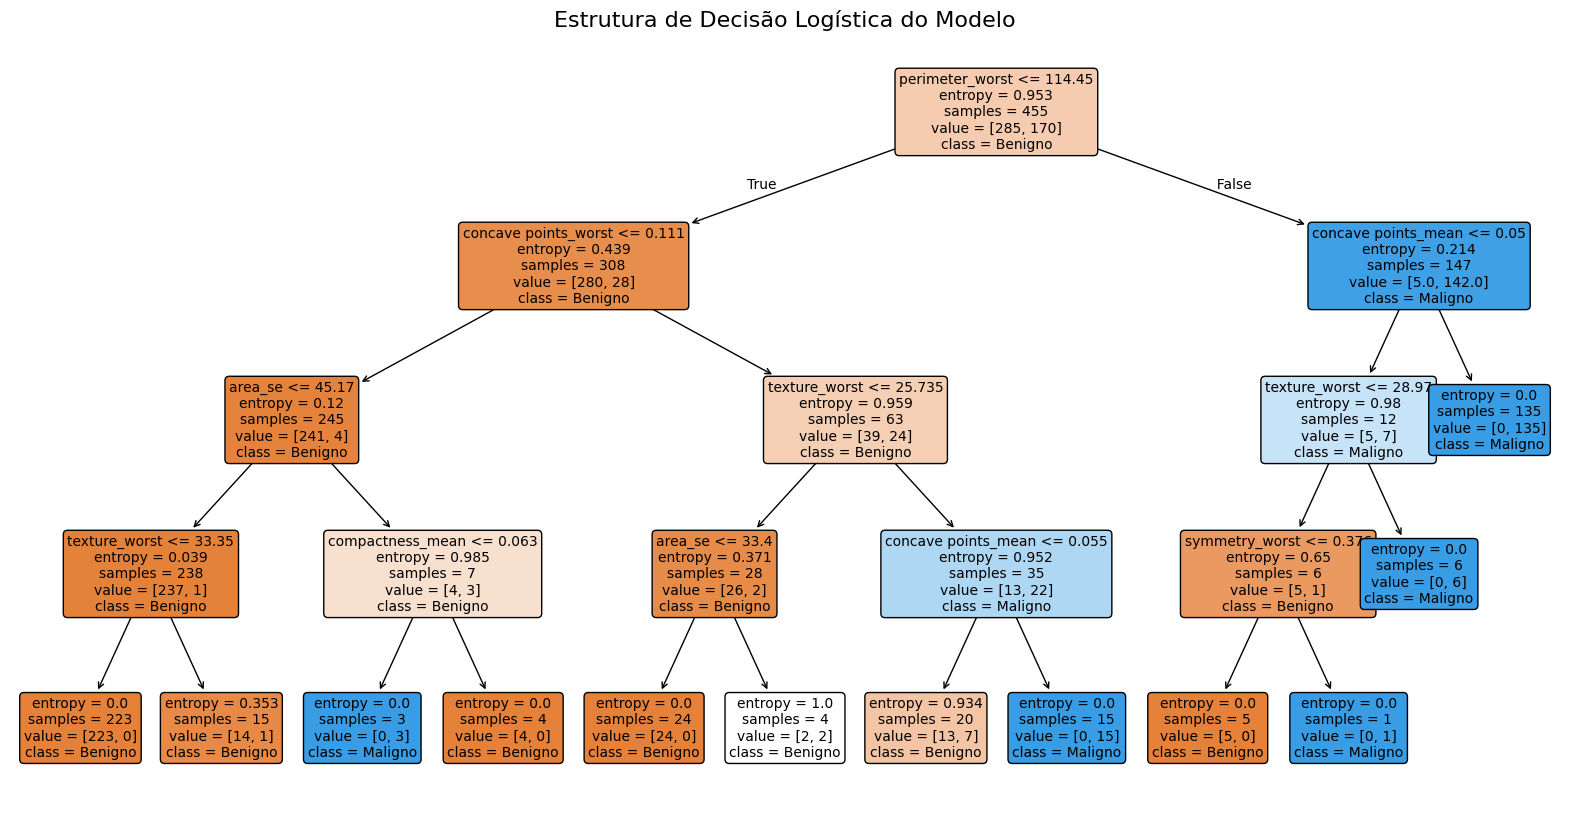

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(
    melhor_arvore,
    feature_names=X.columns,
    class_names=['Benigno', 'Maligno'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Estrutura de Decisão Logística do Modelo", fontsize=16)
plt.show()

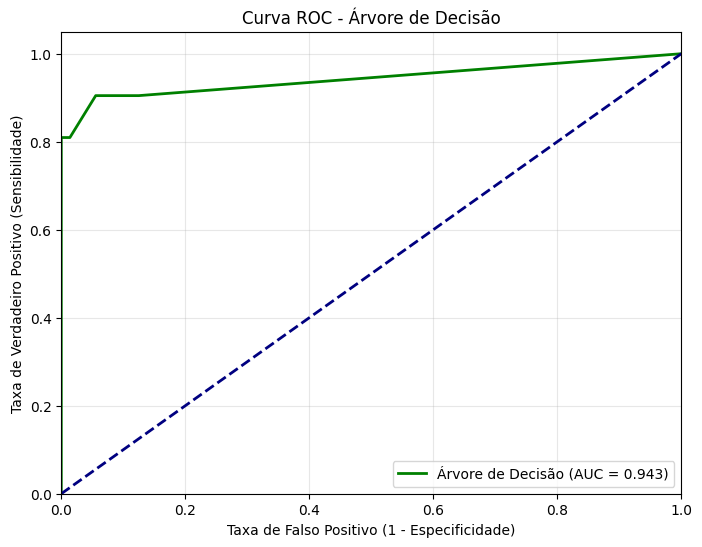

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'Árvore de Decisão (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade)')
plt.title('Curva ROC - Árvore de Decisão')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()